In [11]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

sns.set_context("paper", font_scale=1.3)

---

In [29]:
df = pd.read_csv(
    "/Users/cooper/Desktop/CAMELS-CH/clustering_results/cluster_assignments_shifted.csv"
)

df["country"] = df["gauge_id"].str.split("_").str[0]

cluster_country_counts = df.groupby(["cluster", "country"]).size().unstack(fill_value=0)

print(cluster_country_counts)

country  CH   CL  USA
cluster              
0         0    1   64
1         2  101   83
2         5    6    6
3        20    9   21
4         1   19  115
5         0    1   14
6         2    2  108
7         0    0   14
8        38   30   36
9         0    3   19
10        1   13    0
11        0    7   41
12        0    1   36
13        5   22   96
14       61   18    9


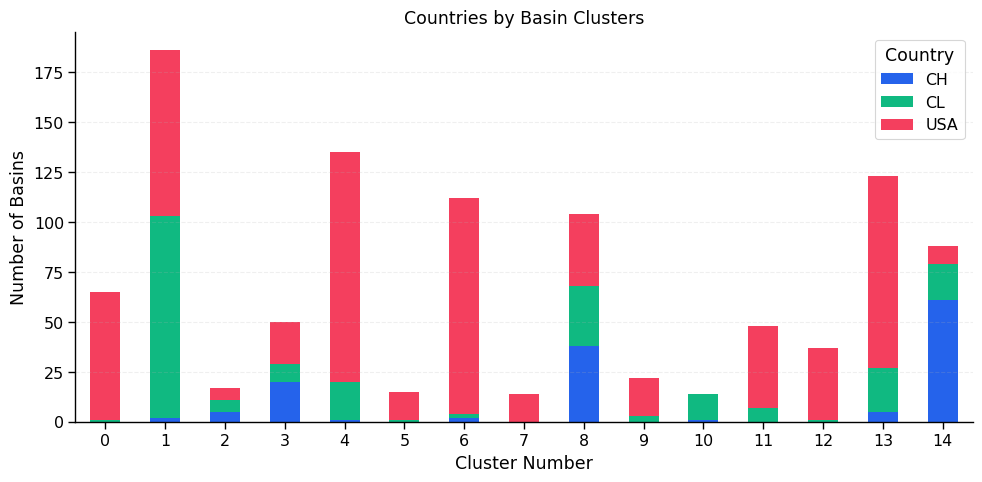

In [33]:
plt.figure(figsize=(10, 5))

palette = ["#2563EB", "#10B981", "#F43F5E"]

cluster_country_counts.plot(kind="bar", stacked=True, color=palette, ax=plt.gca())
plt.title("Countries by Basin Clusters")
plt.xlabel("Cluster Number")
plt.ylabel("Number of Basins")
plt.xticks(rotation=0)

plt.legend(title="Country")

# Add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.2)

plt.tight_layout()

sns.despine()
plt.show()

In [31]:
cluster_sizes = df["cluster"].value_counts().sort_index()

# Print key statistics
print("Cluster Sizes:")
print(cluster_sizes)
print("\nBiggest Cluster:")
print(cluster_sizes.idxmax(), "with", cluster_sizes.max(), "basins")
print("\nSmallest Cluster:")
print(cluster_sizes.idxmin(), "with", cluster_sizes.min(), "basins")

Cluster Sizes:
cluster
0      65
1     186
2      17
3      50
4     135
5      15
6     112
7      14
8     104
9      22
10     14
11     48
12     37
13    123
14     88
Name: count, dtype: int64

Biggest Cluster:
1 with 186 basins

Smallest Cluster:
7 with 14 basins


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist


def calculate_cluster_metrics(basins):
    # Reproject to a suitable UTM zone using the first basin's centroid
    centroid = basins.geometry.centroid.iloc[0]
    utm_zone = int((centroid.x + 180) / 6) + 1
    hemisphere = "north" if centroid.y >= 0 else "south"
    projected_crs = f"+proj=utm +zone={utm_zone} +{hemisphere} +ellps=WGS84 +datum=WGS84 +units=m +no_defs"

    basins_proj = basins.to_crs(projected_crs)
    centroids_proj = basins_proj.geometry.centroid

    # Extract x, y coordinates from centroids
    coords = np.array([(pt.x, pt.y) for pt in centroids_proj])

    # Compute pairwise Euclidean distances (in meters) and convert to kilometers
    distances_m = pdist(coords)
    distances_km = distances_m / 1000.0

    # Calculate basin areas in square kilometers
    basin_areas_km2 = basins_proj.geometry.area / 1_000_000

    return {"distances_km": distances_km, "basin_areas_km2": basin_areas_km2.tolist()}


# Initialize results storage
cluster_metrics = {}

# Assuming df is already defined and has the 'country', 'gauge_id', and 'cluster' columns
for country in df["country"].unique():
    path_to_basins = f"/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/{country}/post_processed/shapefiles/{country}/{country}_basin_shapes.shp"
    basins = gpd.read_file(path_to_basins)
    basins = basins.merge(
        df[["gauge_id", "cluster"]],
        on="gauge_id",
        how="inner",
    )

    # Group by cluster and calculate metrics
    for cluster in basins["cluster"].unique():
        cluster_basins = basins[basins["cluster"] == cluster]
        if len(cluster_basins) > 1:
            metrics = calculate_cluster_metrics(cluster_basins)
            cluster_metrics.setdefault(cluster, {"distances": [], "basin_areas": []})
            cluster_metrics[cluster]["distances"].extend(metrics["distances_km"])
            cluster_metrics[cluster]["basin_areas"].extend(metrics["basin_areas_km2"])

# Print summary statistics
for cluster, metrics in cluster_metrics.items():
    print(f"Cluster {cluster}:")
    print("  Distances:")
    print(f"    Mean distance: {np.mean(metrics['distances']):.2f} km")
    print(f"    Median distance: {np.median(metrics['distances']):.2f} km")
    print(f"    Max distance: {np.max(metrics['distances']):.2f} km")
    print("  Basin Areas:")
    print(f"    Mean area: {np.mean(metrics['basin_areas']):.2f} km²")
    print(f"    Median area: {np.median(metrics['basin_areas']):.2f} km²")
    print(f"    Min area: {np.min(metrics['basin_areas']):.2f} km²")
    print(f"    Max area: {np.max(metrics['basin_areas']):.2f} km²")

Cluster 14:
  Distances:
    Mean distance: 162.06 km
    Median distance: 108.85 km
    Max distance: 2955.01 km
  Basin Areas:
    Mean area: 775.10 km²
    Median area: 305.98 km²
    Min area: 18.84 km²
    Max area: 7568.17 km²
Cluster 3:
  Distances:
    Mean distance: 593.71 km
    Median distance: 193.20 km
    Max distance: 2800.06 km
  Basin Areas:
    Mean area: 1454.02 km²
    Median area: 461.82 km²
    Min area: 25.25 km²
    Max area: 26116.06 km²
Cluster 8:
  Distances:
    Mean distance: 679.34 km
    Median distance: 187.80 km
    Max distance: 4589.79 km
  Basin Areas:
    Mean area: 726.52 km²
    Median area: 273.72 km²
    Min area: 13.73 km²
    Max area: 8851.59 km²
Cluster 2:
  Distances:
    Mean distance: 666.58 km
    Median distance: 156.24 km
    Max distance: 2830.40 km
  Basin Areas:
    Mean area: 1443.24 km²
    Median area: 406.97 km²
    Min area: 75.70 km²
    Max area: 10227.48 km²
Cluster 13:
  Distances:
    Mean distance: 818.37 km
    Median di

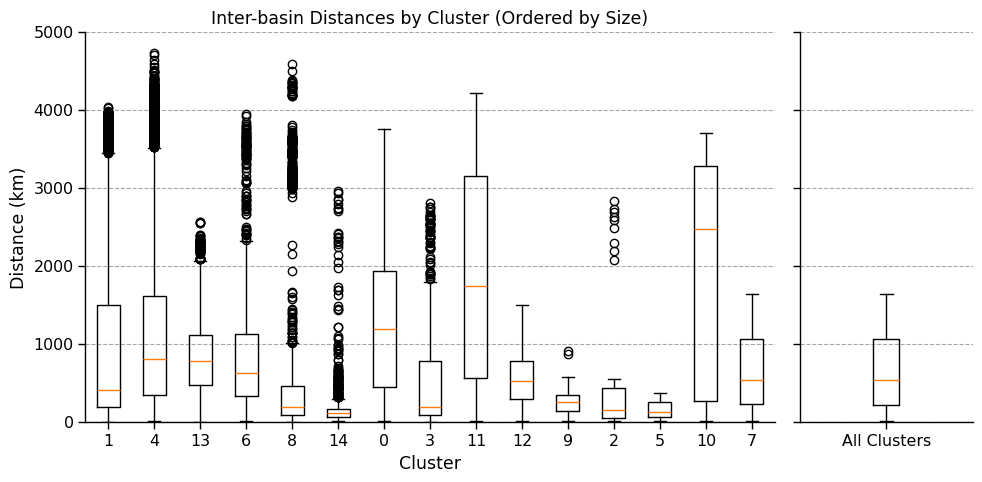

In [25]:
cluster_sizes = df["cluster"].value_counts()

# Order clusters (only those with computed distances) by cluster size (descending order)
ordered_clusters = sorted(
    [c for c in cluster_metrics.keys()], key=lambda c: cluster_sizes[c], reverse=True
)

# Extract distances in the sorted order for individual clusters
ordered_distances = [cluster_metrics[c]["distances"] for c in ordered_clusters]

# Aggregate all distances across clusters
all_distances = []
for distances in cluster_metrics.values():
    all_distances.extend(metrics["distances"])

# Create a 1x2 grid with the first plot larger than the second one using width_ratios
fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={"width_ratios": [4, 1]})

ax[0].yaxis.grid(color="gray", linestyle="--", alpha=0.7)
ax[1].yaxis.grid(color="gray", linestyle="--", alpha=0.7)

# Plot 1: Boxplot of inter-basin distances by cluster (ordered by size)
ax[0].boxplot(ordered_distances, labels=[f"{c}" for c in ordered_clusters])
ax[0].set_ylim(0, 5000)
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Distance (km)")
ax[0].set_title("Inter-basin Distances by Cluster (Ordered by Size)")
sns.despine(ax=ax[0])

# Plot 2: Boxplot with all clusters aggregated
ax[1].boxplot(all_distances, labels=["All Clusters"])
ax[1].set_ylim(0, 5000)
ax[1].set_ylabel("Distance (km)")

# Remove y-axis label for the second plot
ax[1].set_ylabel("")
ax[1].set_yticklabels([])

sns.despine(ax=ax[1])

plt.tight_layout()
plt.show()

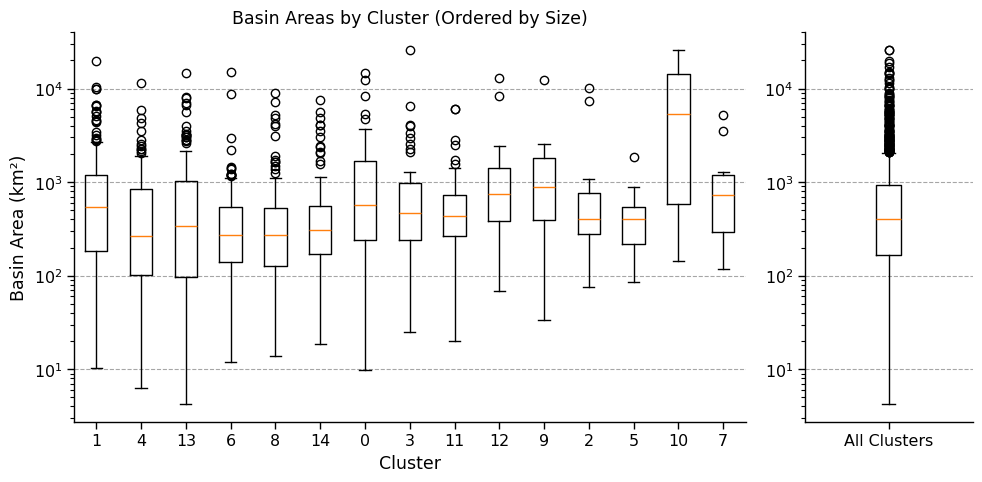

In [27]:
# Order clusters by cluster size (descending order)
ordered_clusters = sorted(
    [c for c in cluster_metrics.keys()], key=lambda c: cluster_sizes[c], reverse=True
)

# Extract basin areas in the sorted order for individual clusters
ordered_areas = [cluster_metrics[c]["basin_areas"] for c in ordered_clusters]

# Aggregate all basin areas across clusters
all_areas = []
for metrics in cluster_metrics.values():
    all_areas.extend(metrics["basin_areas"])

# Create a 1x2 grid with the first plot larger than the second one using width_ratios
fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={"width_ratios": [4, 1]})

ax[0].yaxis.grid(color="gray", linestyle="--", alpha=0.7)
ax[1].yaxis.grid(color="gray", linestyle="--", alpha=0.7)

# Plot 1: Boxplot of basin areas by cluster (ordered by size)
ax[0].boxplot(ordered_areas, labels=[f"{c}" for c in ordered_clusters])
ax[0].set_xlabel("Cluster")
ax[0].set_ylabel("Basin Area (km²)")
ax[0].set_title("Basin Areas by Cluster (Ordered by Size)")
sns.despine(ax=ax[0])

# Plot 2: Boxplot with all clusters aggregated
ax[1].boxplot(all_areas, labels=["All Clusters"])
ax[1].set_ylabel("Basin Area (km²)")

# Remove y-axis label for the second plot
ax[1].set_ylabel("")
ax[1].set_yticklabels([])

# Make y axis log scale
ax[0].set_yscale("log")
ax[1].set_yscale("log")

sns.despine(ax=ax[1])
plt.tight_layout()
plt.show()